#### ML Model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('..\\data\\processed\\master_df.csv')
print(df.shape)
df.head()

(7043, 50)


,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Referred a Friend,Number of Referrals,...,CLTV,Churn Category,Churn Reason,Country,State,City,Zip Code,Lat Long,Latitude,Longitude
0,8779-QRDMV,Male,78,No,Yes,No,No,0,No,0,...,5433,Competitor,Competitor offered more data,United States,California,Los Angeles,90022,"34.02381, -118.156582",34.023810,-118.156582
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,Yes,1,...,5302,Competitor,Competitor made better offer,United States,California,Los Angeles,90063,"34.044271, -118.185237",34.044271,-118.185237
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,No,0,...,3179,Competitor,Competitor made better offer,United States,California,Los Angeles,90065,"34.108833, -118.229715",34.108833,-118.229715
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,Yes,1,...,5337,Dissatisfaction,Limited range of services,United States,California,Inglewood,90303,"33.936291, -118.332639",33.936291,-118.332639
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,Yes,1,...,2793,Price,Extra data charges,United States,California,Whittier,90602,"33.972119, -118.020188",33.972119,-118.020188


#### Feature Selection

In [3]:
cols_to_drop = [
    'Customer ID',
    'Churn Category', 'Churn Reason', 'Churn Score',
    'CLTV',
    'Zip Code', 'Latitude', 'Longitude', 'City', 'Country', 'State'
]

df_model = df.drop(columns=cols_to_drop)
print(df_model.shape)

(7043, 39)


In [4]:
df_model.dtypes.value_counts()

str        25
int64       8
float64     6
Name: count, dtype: int64

In [5]:
df_model.select_dtypes(include='object').columns.tolist()

['Gender',
 'Under 30',
 'Senior Citizen',
 'Married',
 'Dependents',
 'Referred a Friend',
 'Offer',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Customer Status',
 'Churn Label',
 'Lat Long']

In [6]:
df_model['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
print(df_model['Churn Value'].value_counts())

Churn Value
0    5174
1    1869
Name: count, dtype: int64


In [8]:
df_model['Customer Status'].value_counts()

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

In [9]:
df_model = df_model.drop(columns=['Churn Label', 'Customer Status'])
print(df_model.shape)

(7043, 37)


In [10]:
df_model = df_model.drop(columns=['Lat Long'])
print(df_model.shape)

(7043, 36)


In [11]:
df_model.select_dtypes(include='object').columns.tolist()

['Gender',
 'Under 30',
 'Senior Citizen',
 'Married',
 'Dependents',
 'Referred a Friend',
 'Offer',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method']

In [12]:
for col in df_model.select_dtypes(include='object').columns:
    print(f"{col}: {df_model[col].unique()}")

Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Under 30: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Senior Citizen: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Married: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Referred a Friend: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Offer: <StringArray>
['No Offer', 'Offer E', 'Offer D', 'Offer C', 'Offer B', 'Offer A']
Length: 6, dtype: str
Phone Service: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Multiple Lines: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Internet Service: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Internet Type: <StringArray>
['DSL', 'Fiber Optic', 'Cable', 'No Internet']
Length: 4, dtype: str
Online Security: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Online Backup: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Device Protection Plan: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Premium

In [13]:
binary_cols = [
    'Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
    'Referred a Friend', 'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection Plan',
    'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
    'Streaming Music', 'Unlimited Data', 'Paperless Billing'
]

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

df_model[binary_cols] = df_model[binary_cols].replace(binary_map)

print(df_model[binary_cols].dtypes.value_counts())

object    18
Name: count, dtype: int64


In [14]:
df_model[binary_cols] = df_model[binary_cols].replace(binary_map).astype(int)
print(df_model[binary_cols].dtypes.value_counts())

int64    18
Name: count, dtype: int64


In [15]:
df_model = pd.get_dummies(df_model, columns=['Offer', 'Internet Type', 'Contract', 'Payment Method'])
print(df_model.shape)

(7043, 48)


In [16]:
df_model.select_dtypes(include='object').columns.tolist()

[]

In [17]:
print(df_model.shape)
print(df_model.dtypes.value_counts())

(7043, 48)
int64      26
bool       16
float64     6
Name: count, dtype: int64


In [18]:
bool_cols = df_model.select_dtypes(include='bool').columns.tolist()
df_model[bool_cols] = df_model[bool_cols].astype(int)
print(df_model.dtypes.value_counts())

int64      42
float64     6
Name: count, dtype: int64


In [19]:
X = df_model.drop(columns=['Churn Value'])
y = df_model['Churn Value']

print(X.shape)
print(y.value_counts())

(7043, 47)
Churn Value
0    5174
1    1869
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 47)
(1409, 47)
Churn Value
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn Value
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Done")

Done


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96      1035
           1       0.85      0.93      0.89       374

    accuracy                           0.94      1409
   macro avg       0.91      0.93      0.92      1409
weighted avg       0.94      0.94      0.94      1409



In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1035
           1       0.93      0.91      0.92       374

    accuracy                           0.96      1409
   macro avg       0.95      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



In [24]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1035
           1       0.97      0.89      0.93       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



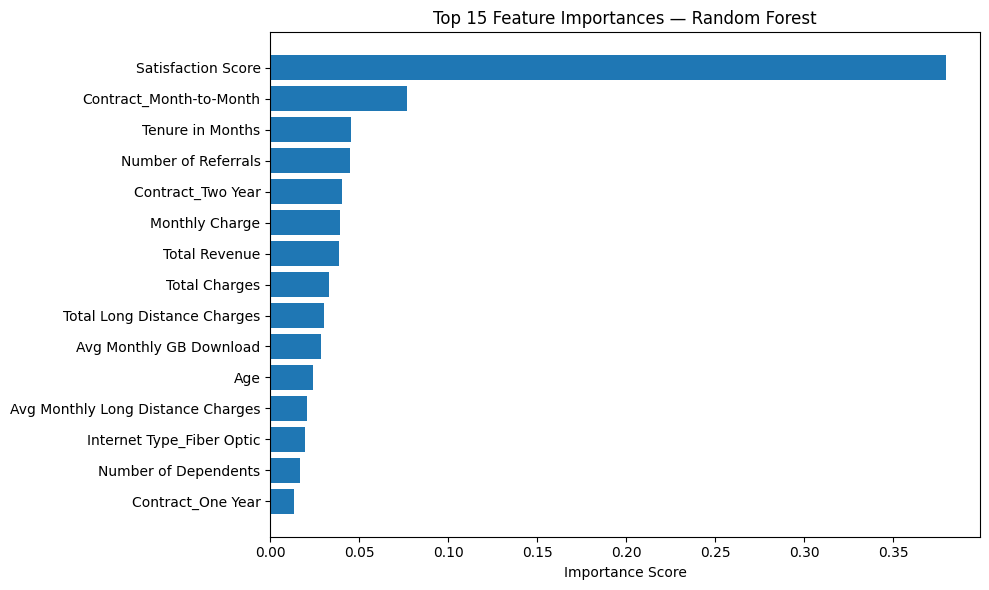

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.index[::-1], feature_importance.values[::-1])
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [26]:
import joblib

joblib.dump(rf, 'e:\\Projects\\customer-churn-project\\models\\rf_churn_model.pkl')
print("Model saved")

Model saved


In [27]:
churn_proba = rf.predict_proba(X)[:, 1]
df['Churn Probability'] = churn_proba
print(df[['Churn Probability']].describe())

       Churn Probability
count        7043.000000
mean            0.295522
std             0.402835
min             0.000000
25%             0.020000
50%             0.060000
75%             0.830000
max             1.000000


In [28]:
rfm_segments = pd.read_csv('e:\\Projects\\customer-churn-project\\data\\processed\\rfm_segments.csv')
print(rfm_segments.shape)
print(rfm_segments.head())

(7043, 2)
  Customer ID      RFM_Segment
0  8779-QRDMV             Lost
1  7495-OOKFY          At Risk
2  1658-BYGOY          At Risk
3  4598-XLKNJ  Loyal Customers
4  4846-WHAFZ  Loyal Customers


In [29]:
df_final = df[['Customer ID', 'Churn Value', 'Churn Probability']].copy()
df_final = df_final.merge(rfm_segments, on='Customer ID', how='left')

print(df_final.shape)
print(df_final.head())

(7043, 4)
  Customer ID  Churn Value  Churn Probability      RFM_Segment
0  8779-QRDMV            1               0.99             Lost
1  7495-OOKFY            1               0.92          At Risk
2  1658-BYGOY            1               0.97          At Risk
3  4598-XLKNJ            1               0.97  Loyal Customers
4  4846-WHAFZ            1               0.96  Loyal Customers


In [30]:
segment_summary = df_final.groupby('RFM_Segment').agg(
    Total_Customers=('Customer ID', 'count'),
    Avg_Churn_Probability=('Churn Probability', 'mean'),
    Actual_Churned=('Churn Value', 'sum')
).round(2)

segment_summary['Churn_Rate_%'] = (
    segment_summary['Actual_Churned'] / segment_summary['Total_Customers'] * 100
).round(1)

segment_summary = segment_summary.sort_values('Avg_Churn_Probability', ascending=False)
print(segment_summary)

                 Total_Customers  Avg_Churn_Probability  Actual_Churned  \
RFM_Segment                                                               
Lost                        1737                   0.54             879   
At Risk                     1527                   0.34             460   
Loyal Customers             2384                   0.21             439   
Champions                   1395                   0.08              91   

                 Churn_Rate_%  
RFM_Segment                    
Lost                     50.6  
At Risk                  30.1  
Loyal Customers          18.4  
Champions                 6.5  


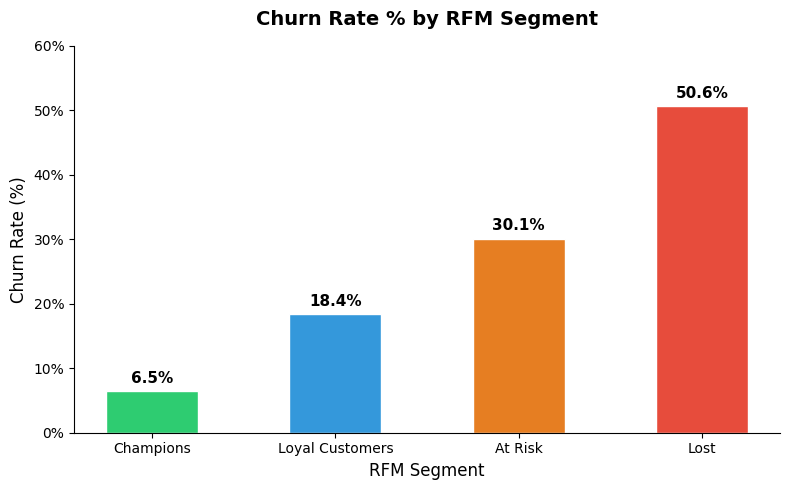

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Data from segment summary
segments = ['Champions', 'Loyal Customers', 'At Risk', 'Lost']
churn_rates = [6.5, 18.4, 30.1, 50.6]

colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(segments, churn_rates, color=colors, width=0.5, edgecolor='white')

# Add value labels on top of each bar
for bar, rate in zip(bars, churn_rates):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{rate}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate % by RFM Segment', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('RFM Segment', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 60)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rfm_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()

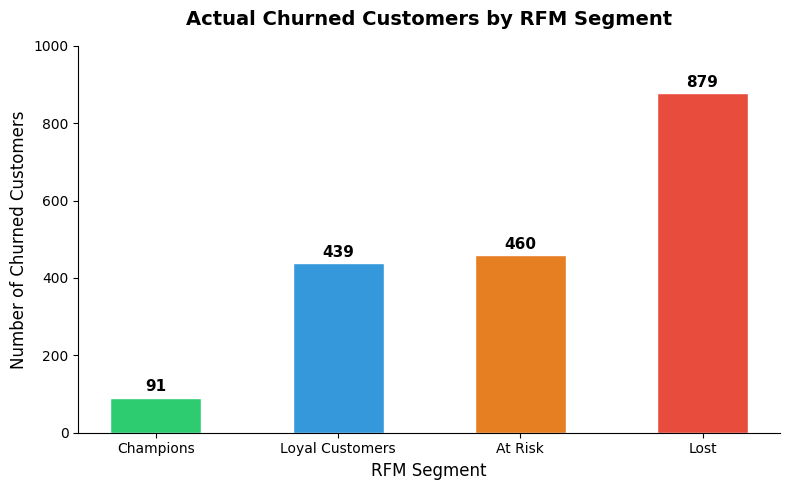

In [32]:
segments = ['Champions', 'Loyal Customers', 'At Risk', 'Lost']
churned_counts = [91, 439, 460, 879]

colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(segments, churned_counts, color=colors, width=0.5, edgecolor='white')

for bar, count in zip(bars, churned_counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8,
            str(count),
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Actual Churned Customers by RFM Segment', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('RFM Segment', fontsize=12)
ax.set_ylabel('Number of Churned Customers', fontsize=12)
ax.set_ylim(0, 1000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rfm_churn_count.png', dpi=150, bbox_inches='tight')
plt.show()

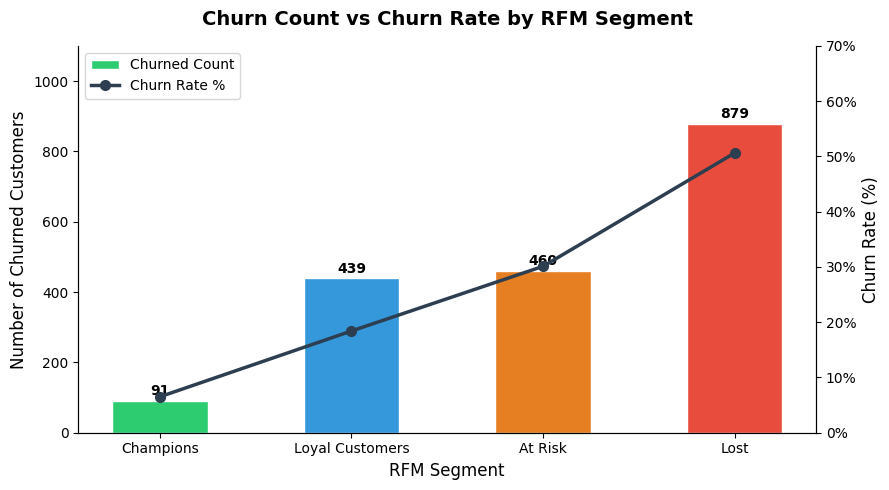

In [33]:
fig, ax1 = plt.subplots(figsize=(9, 5))

# Bar chart — churned count (left axis)
bars = ax1.bar(segments, churned_counts, color=colors, width=0.5, edgecolor='white', label='Churned Count')
ax1.set_ylabel('Number of Churned Customers', fontsize=12)
ax1.set_ylim(0, 1100)
ax1.spines['top'].set_visible(False)

# Line chart — churn rate % (right axis)
ax2 = ax1.twinx()
ax2.plot(segments, churn_rates, color='#2c3e50', marker='o', linewidth=2.5, markersize=7, label='Churn Rate %')
ax2.set_ylabel('Churn Rate (%)', fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylim(0, 70)
ax2.spines['top'].set_visible(False)

# Labels on bars
for bar, count in zip(bars, churned_counts):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 8,
             str(count),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Churn Count vs Churn Rate by RFM Segment', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('RFM Segment', fontsize=12)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('rfm_churn_combined.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
import pandas as pd

# Pull feature importances directly from trained model
feature_names = X_train.columns.tolist()
importances = rf.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

print(feat_df)

                        Feature  Importance
30           Satisfaction Score    0.379902
41      Contract_Month-to-Month    0.077082
9              Tenure in Months    0.045438
8           Number of Referrals    0.045017
43            Contract_Two Year    0.040069
24               Monthly Charge    0.039075
29                Total Revenue    0.038805
25                Total Charges    0.032845
28  Total Long Distance Charges    0.030117
14      Avg Monthly GB Download    0.028409


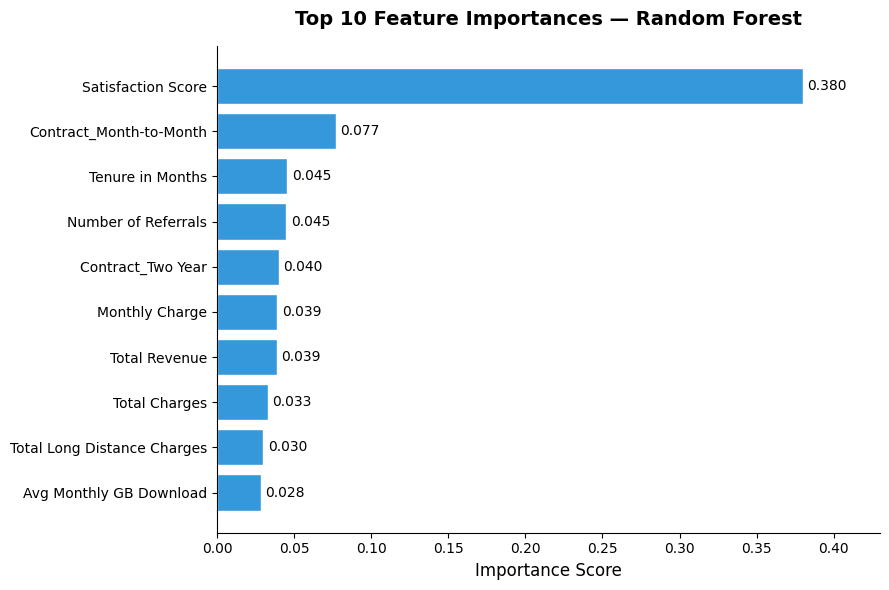

In [35]:
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(feat_df['Feature'][::-1], 
               feat_df['Importance'][::-1], 
               color='#3498db', edgecolor='white')

# Value labels on each bar
for bar, val in zip(bars, feat_df['Importance'][::-1]):
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center', fontsize=10)

ax.set_title('Top 10 Feature Importances — Random Forest', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_xlim(0, 0.43)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

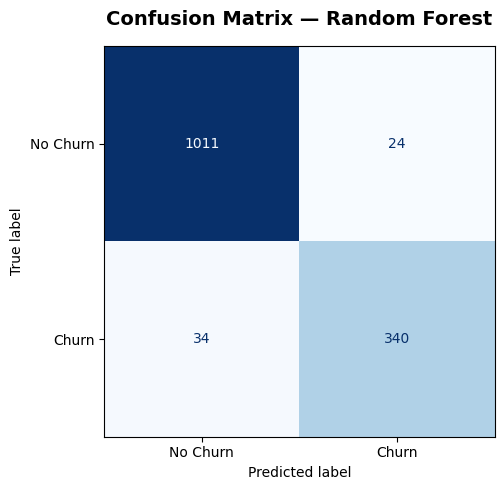

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
type(rf)

sklearn.ensemble._forest.RandomForestClassifier

In [38]:
print(rf)
print(X_train.shape)
print(X_test.shape)
X_train.columns[:10]

RandomForestClassifier(class_weight='balanced', random_state=42)
(5634, 47)
(1409, 47)


Index(['Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
       'Number of Dependents', 'Referred a Friend', 'Number of Referrals',
       'Tenure in Months'],
      dtype='str')

In [39]:
import shap
print(shap.__version__)

0.51.0


In [40]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

In [41]:
type(shap_values)

numpy.ndarray

In [42]:
import numpy as np

np.array(shap_values).shape

(1409, 47, 2)

In [43]:
shap_class1 = shap_values[:, :, 1]

print(shap_class1.shape)

(1409, 47)


In [44]:
print(len(X_test.columns))
print(shap_class1.shape[1])

47
47


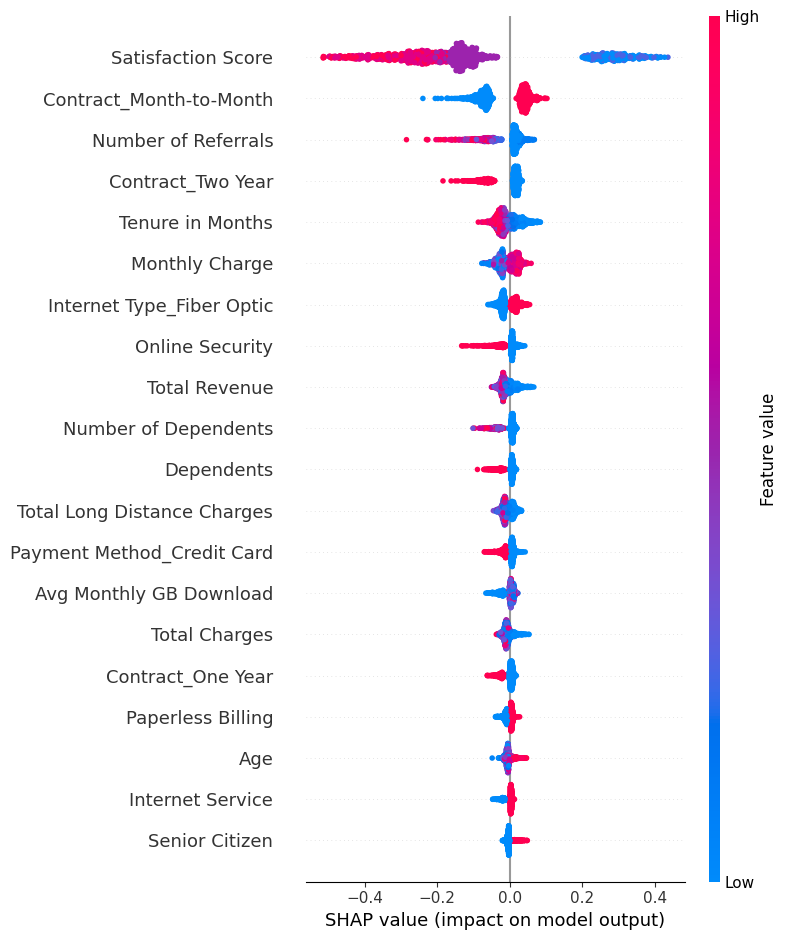

In [45]:
import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_class1,
    X_test,
    show=False
)

plt.tight_layout()
plt.show()

In [46]:
probs = rf.predict_proba(X_test)[:, 1]

highest_idx = probs.argmax()

print("Index:", highest_idx)
print("Probability:", probs[highest_idx])

Index: 26
Probability: 1.0


In [47]:
X_test.iloc[highest_idx]

Gender                                 0.00
Age                                   73.00
Under 30                               0.00
Senior Citizen                         1.00
Married                                1.00
Dependents                             0.00
Number of Dependents                   0.00
Referred a Friend                      1.00
Number of Referrals                    1.00
Tenure in Months                       1.00
Phone Service                          1.00
Avg Monthly Long Distance Charges     37.30
Multiple Lines                         0.00
Internet Service                       1.00
Avg Monthly GB Download                8.00
Online Security                        0.00
Online Backup                          0.00
Device Protection Plan                 0.00
Premium Tech Support                   0.00
Streaming TV                           0.00
Streaming Movies                       0.00
Streaming Music                        0.00
Unlimited Data                  

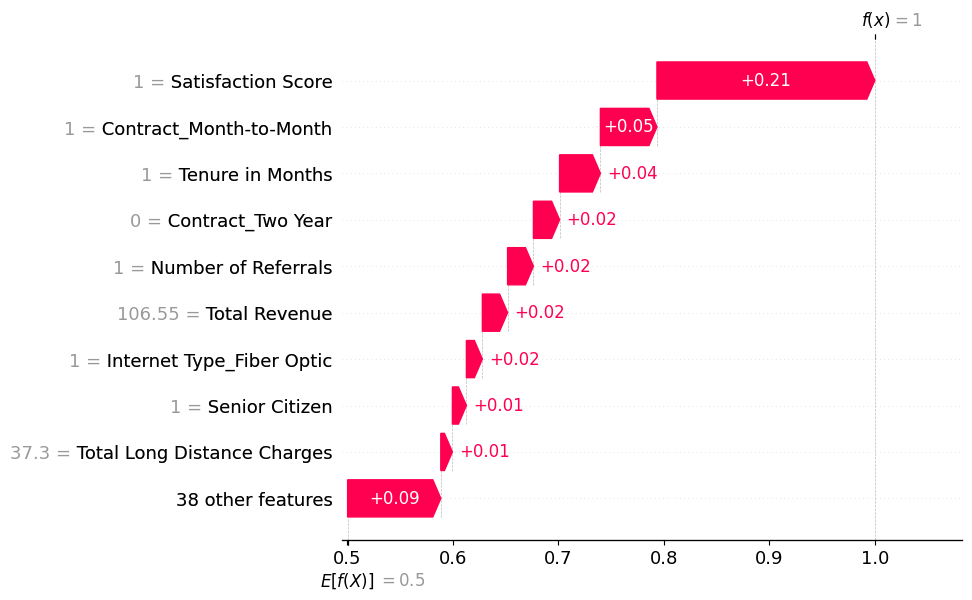

In [48]:
import shap

explanation = shap.Explanation(
    values=shap_values[highest_idx, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[highest_idx],
    feature_names=X_test.columns
)

shap.plots.waterfall(explanation, max_display=10)

In [49]:
import joblib

type(rf)

sklearn.ensemble._forest.RandomForestClassifier

In [50]:
# Load the 4 RFM segments we created in notebook 03
rfm_for_export = pd.read_csv('../data/processed/rfm_segments.csv')

# Build the export DataFrame from the training DataFrame (df)
# df already has 'Churn Probability' from cell 27
export_df = df[['Customer ID', 'Churn Probability', 'Churn Value', 'Total Revenue']].copy()

# Attach the RFM segment label to each customer
export_df = export_df.merge(rfm_for_export, on='Customer ID', how='left')

# Preview to confirm
print(export_df.shape)
print(export_df.head())
print(export_df['RFM_Segment'].value_counts())

# Save — new file, master_df.csv stays untouched
export_df.to_csv('../data/processed/customer_data_with_predictions.csv', index=False)
print("Saved: customer_data_with_predictions.csv")

(7043, 5)
  Customer ID  Churn Probability  Churn Value  Total Revenue      RFM_Segment
0  8779-QRDMV               0.99            1          59.65             Lost
1  7495-OOKFY               0.92            1        1024.10          At Risk
2  1658-BYGOY               0.97            1        1910.88          At Risk
3  4598-XLKNJ               0.97            1        2995.07  Loyal Customers
4  4846-WHAFZ               0.96            1        3102.36  Loyal Customers
RFM_Segment
Loyal Customers    2384
Lost               1737
At Risk            1527
Champions          1395
Name: count, dtype: int64
Saved: customer_data_with_predictions.csv


In [51]:
import joblib

# Save the SHAP TreeExplainer (already built in cell 44)
joblib.dump(explainer, '../models/shap_explainer.pkl')

# Save the feature names — the app needs to know the exact 47-column order
feature_names = X_train.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.pkl')

print("Saved: shap_explainer.pkl")
print("Saved: feature_names.pkl")
print(f"Features: {len(feature_names)} columns")

Saved: shap_explainer.pkl
Saved: feature_names.pkl
Features: 47 columns


In [ ]:
# Save encoding mappings for the Streamlit app
encoding_config = {
    'binary_cols': [
        'Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents',
        'Referred a Friend', 'Phone Service', 'Multiple Lines', 'Internet Service',
        'Online Security', 'Online Backup', 'Device Protection Plan',
        'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
        'Streaming Music', 'Unlimited Data', 'Paperless Billing'
    ],
    'binary_map': {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0},
    'onehot_cols': ['Offer', 'Internet Type', 'Contract', 'Payment Method'],
    'onehot_categories': {
        'Offer': ['No Offer', 'Offer A', 'Offer B', 'Offer C', 'Offer D', 'Offer E'],
        'Internet Type': ['Cable', 'DSL', 'Fiber Optic', 'No Internet'],
        'Contract': ['Month-to-Month', 'One Year', 'Two Year'],
        'Payment Method': ['Bank Withdrawal', 'Credit Card', 'Mailed Check']
    },
    'numeric_cols': [
        'Age', 'Number of Dependents', 'Number of Referrals',
        'Tenure in Months', 'Avg Monthly Long Distance Charges',
        'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges',
        'Total Refunds', 'Total Extra Data Charges',
        'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score'
    ]
}

joblib.dump(encoding_config, '../models/encoding_config.pkl')
print("Saved: encoding_config.pkl")
print(f"Binary columns: {len(encoding_config['binary_cols'])}")
print(f"One-hot groups: {len(encoding_config['onehot_cols'])}")
print(f"Numeric columns: {len(encoding_config['numeric_cols'])}")
print(f"Total: {18 + 16 + 13} = 47 ✓")

Saved: encoding_config.pkl
Binary columns: 18
One-hot groups: 4
Numeric columns: 13
Total: 47 = 47 ✓


: 